In [1]:
#1) IMPORT NECESSARY LIBRARIES

import pandas as pd
import pmdarima as pm
from prophet import Prophet
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
#2) LOAD THE DATA
data=pd.read_csv('/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/Type of analysis/Analisis temporal/merged files/csv/microsoft/microsoft_data.csv')

In [3]:
#3) DO SOME CLEANING IF NECESSARY

data = data.drop(columns=['Unnamed: 0'])

data = data.rename(columns={"date": "ds", "Price": "y"})

data["ds"]= pd.to_datetime(data["ds"], format="%Y-%m-%d", errors="coerce")

#reorder columns
data = data[["ds", "y", "revenue_musd", "net_income_musd", "total_assets_musd","total_liabilities_musd", "share_holder_equity_musd", "gdp_growth", "interest_rate"]]

In [4]:
#4) CREATE BACKTESTING DATASET

data_bt = data.iloc[:-4]

START THE SET UP FOR THE PROPHET MODEL

In [5]:
#5) ADD A FUTURE BASE SCENARIO SO PROPHET CAN FORECAST

# ================== CONFIG ==================
FUTURE_PERIODS = 4    # nº of quarters to forecast
FREQ = "Q"            # trimestral frecuency
REG_COLS = ["revenue_musd", "net_income_musd", "total_assets_musd","total_liabilities_musd",  "share_holder_equity_musd", "gdp_growth", "interest_rate"]
# ================== PREP ====================
df = data.copy()

# Make sure that the regressors exist (if any are missing, we create them as Nan)  
for c in REG_COLS:
    if c not in df.columns:
        df[c] = np.nan

# Convert gdp_growth to numeric if it's not already
if df["gdp_growth"].dtype == "object":
    df["gdp_growth"] = (
        df["gdp_growth"].astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False)
        .replace({"": np.nan}).astype(float)
    )

# Fill empty slots with forward-fill (opcional but usefull for training)
df[REG_COLS] = df[REG_COLS].ffill()

In [6]:
#5) ADD A FUTURE BASE SCENARIO SO PROPHET CAN FORECAST - BACKTESTING DATASET

# ================== PREP ====================
df_bt = data_bt.copy()

# Make sure that the regressors exist (if any are missing, we create them as Nan)  
for c in REG_COLS:
    if c not in df_bt.columns:
        df_bt[c] = np.nan

# Convert gdp_growth to numeric if it's not already
if df_bt["gdp_growth"].dtype == "object":
    df_bt["gdp_growth"] = (
        df_bt["gdp_growth"].astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False)
        .replace({"": np.nan}).astype(float)
    )

# Fill empty slots with forward-fill (opcional but usefull for training)
df_bt[REG_COLS] = df_bt[REG_COLS].ffill()

SET UP THE ARIMA MODEL TO FORECAST THE REGRESSORS

In [7]:
# 6) CREATE ARIMA MODEL TO FORECAST REGRESSORS
# ================== FUTURE SCENARIO ==================

revenue = data.set_index("ds")["revenue_musd"]
net_income = data.set_index("ds")["net_income_musd"]
total_assets = data.set_index("ds")["total_assets_musd"]
total_liabilities = data.set_index("ds")["total_liabilities_musd"]
total_equity = data.set_index("ds")["share_holder_equity_musd"]

metrics = {
    "revenue":revenue,
    "net_income": net_income,
    "total_assets": total_assets,
    "total_liabilities": total_liabilities,
    "total_equity": total_equity
    }

results = {}

for name, series in metrics.items():
    print(f"\nFitting model for {name}...")
    model = pm.auto_arima(
        series,
        seasonal=True, m=4,
        d=None, D=None,
        start_p=0, start_q=0, max_p=5, max_q=5,
        start_P=0, start_Q=0, max_P=2, max_Q=2,
        stepwise=True,
        information_criterion="aic",
        test="adf", seasonal_test="ocsb",
        suppress_warnings=True, error_action="ignore",
        allowdrift=True,
        trace=False,   # put True if you want detailed search output
    )
    results[name] = model
    print(f"Best order for {name}: {model.order}, seasonal: {model.seasonal_order}")

forecast_dic = {}

for name, model in results.items():
    fc = model.predict(n_periods=4)
    forecast_dic[name] = fc
    print(f"\n-{name} forecast for next 4 quarters:")
    print(fc)

/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1


Fitting model for revenue...


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

Best order for revenue: (1, 2, 1), seasonal: (1, 0, 1, 4)

Fitting model for net_income...


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

...

/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

Best order for total_liabilities: (3, 2, 0), seasonal: (1, 0, 0, 4)

Fitting model for total_equity...


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

Best order for total_equity: (0, 2, 2), seasonal: (0, 0, 0, 4)

-revenue forecast for next 4 quarters:
2025-09-30    76462.496650
2025-12-31    81235.166762
2026-03-31    81902.291608
2026-06-30    86028.966241
Freq: QE-DEC, dtype: float64

-net_income forecast for next 4 quarters:
2025-09-30    26283.577526
2025-12-31    26644.731032
2026-03-31    27005.884538
2026-06-30    27367.038043
Freq: QE-DEC, dtype: float64

-total_assets forecast for next 4 quarters:
2025-09-30    657454.615058
2025-12-31    687813.982437
2026-03-31    715511.024751
2026-06-30    751351.133851
Freq: QE-DEC, dtype: float64

-total_liabilities forecast for next 4 quarters:
2025-09-30    289632.717432
2025-12-31    295057.084316
2026-03-31    296494.097866
2026-06-30    312391.631373
Freq: QE-DEC, dtype: float64

-total_equity forecast for next 4 quarters:
2025-09-30    362490.367193
2025-12-31    380483.749556
2026-03-31    398477.131919
2026-06-30    416470.514283
Freq: QE-DEC, dtype: float64


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

In [8]:
# 6) CREATE ARIMA MODEL TO FORECAST REGRESSORS - BACKTESTING DATA
# ================== FUTURE SCENARIO ==================

revenue_bt = data_bt.set_index("ds")["revenue_musd"]
net_income_bt = data_bt.set_index("ds")["net_income_musd"]
total_assets_bt = data_bt.set_index("ds")["total_assets_musd"]
total_liabilities_bt = data_bt.set_index("ds")["total_liabilities_musd"]
total_equity_bt = data_bt.set_index("ds")["share_holder_equity_musd"]

metrics_bt = {
    "revenue":revenue_bt,
    "net_income": net_income_bt,
    "total_assets": total_assets_bt,
    "total_liabilities": total_liabilities_bt,
    "total_equity": total_equity_bt
    }

results_bt = {}

for name, series in metrics_bt.items():
    print(f"\nFitting model for {name}...")
    model_bt = pm.auto_arima(
        series,
        seasonal=True, m=4,
        d=None, D=None,
        start_p=0, start_q=0, max_p=5, max_q=5,
        start_P=0, start_Q=0, max_P=2, max_Q=2,
        stepwise=True,
        information_criterion="aic",
        test="adf", seasonal_test="ocsb",
        suppress_warnings=True, error_action="ignore",
        allowdrift=True,
        trace=False,   # put True if you want detailed search output
    )
    results_bt[name] = model_bt
    print(f"Best order for {name}: {model_bt.order}, seasonal: {model_bt.seasonal_order}")

forecast_dic_bt = {}

for name, model in results_bt.items():
    fc_bt = model.predict(n_periods=4)
    forecast_dic_bt[name] = fc_bt
    print(f"\n-{name} forecast for next 4 quarters:")
    print(fc_bt)

/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1


Fitting model for revenue...


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

Best order for revenue: (1, 2, 1), seasonal: (1, 0, 1, 4)

Fitting model for net_income...


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

...

/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

Best order for total_liabilities: (3, 2, 0), seasonal: (1, 0, 0, 4)

Fitting model for total_equity...


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

Best order for total_equity: (0, 2, 2), seasonal: (0, 0, 0, 4)

-revenue forecast for next 4 quarters:
2024-09-30    65067.460648
2024-12-31    69133.042864
2025-03-31    69231.628380
2025-06-30    72198.912910
Freq: QE-DEC, dtype: float64

-net_income forecast for next 4 quarters:
2024-09-30    22263.915436
2024-12-31    22581.310891
2025-03-31    22898.706346
2025-06-30    23216.101801
Freq: QE-DEC, dtype: float64

-total_assets forecast for next 4 quarters:
2024-09-30    530452.033108
2024-12-31    546896.673067
2025-03-31    561484.852232
2025-06-30    583012.355030
Freq: QE-DEC, dtype: float64

-total_liabilities forecast for next 4 quarters:
2024-09-30    252042.432540
2024-12-31    258477.662828
2025-03-31    261287.824537
2025-06-30    272143.924966
Freq: QE-DEC, dtype: float64

-total_equity forecast for next 4 quarters:
2024-09-30    282653.333207
2024-12-31    295977.951572
2025-03-31    309302.569937
2025-06-30    322627.188302
Freq: QE-DEC, dtype: float64


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

In [9]:
#7) Create future dataframe for Prophet
# ================== FUTURE SCENARIO ==================
# Último punto observado
last = df.sort_values("ds").iloc[-1]

# Fechas futuras
future_dates = pd.date_range(start=df["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]
future = pd.DataFrame({"ds": future_dates})

# gdp_growth: mantener último valor (o define tu propio escenario macro)
future["gdp_growth"] = last["gdp_growth"]
# interest_rate: mantener último valor (o define tu propio escenario macro)
future["interest_rate"] = last["interest_rate"]

# Combina histórico (con y) y futuro (sin y)
hist = df[["ds", "y"] + REG_COLS].copy()
future_full = pd.concat([hist, future], ignore_index=True)

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_27827/659787550.py:7: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates = pd.date_range(start=df["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]


In [10]:
future_full

,ds,y,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd,gdp_growth,interest_rate
0,2009-03-31,13.531229,13648.0,2977.0,68853.0,31910.0,36943.0,-3.23,0.15
1,2009-06-30,17.620026,13099.0,3045.0,77888.0,38330.0,39558.0,-3.98,0.16
2,2009-09-30,19.172707,12920.0,3574.0,81612.0,40400.0,41212.0,-3.13,0.12
3,2009-12-31,22.821438,19022.0,6662.0,82096.0,37813.0,44283.0,0.11,0.11
4,2010-03-31,22.032991,14503.0,4006.0,84910.0,39200.0,45710.0,1.75,0.20
...,...,...,...,...,...,...,...,...,...
65,2025-06-30,496.593658,76441.0,27233.0,619003.0,275524.0,343479.0,1.99,4.33
66,2025-09-30,NaN,NaN,NaN,NaN,NaN,NaN,1.99,4.33
67,2025-12-31,NaN,NaN,NaN,NaN,NaN,NaN,1.99,4.33
68,2026-03-31,NaN,NaN,NaN,NaN,NaN,NaN,1.99,4.33


In [11]:
#7) Create future dataframe for Prophet - BACKTESTING DATA
# ================== FUTURE SCENARIO ==================
# Último punto observado
last_bt = df_bt.sort_values("ds").iloc[-1]

# Fechas futuras
future_dates_bt = pd.date_range(start=df_bt["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]
future_bt = pd.DataFrame({"ds": future_dates_bt})

# gdp_growth: mantener último valor (o define tu propio escenario macro)
future_bt["gdp_growth"] = last_bt["gdp_growth"]
# interest_rate: mantener último valor (o define tu propio escenario macro)
future_bt["interest_rate"] = last_bt["interest_rate"]

# Combina histórico (con y) y futuro (sin y)
hist_bt = df_bt[["ds", "y"] + REG_COLS].copy()
future_full_bt = pd.concat([hist_bt, future_bt], ignore_index=True)

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_27827/785312754.py:7: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates_bt = pd.date_range(start=df_bt["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]


In [12]:
#8) CREATE A DF WITH THE FORECASTED REGRESSORS WITH ARIMA
forecast_dic = pd.DataFrame(forecast_dic)
forecast_dic = forecast_dic.rename(columns={
    "revenue": "revenue_musd",
    "net_income": "net_income_musd",
    "total_assets": "total_assets_musd",
    "total_liabilities": "total_liabilities_musd",
    "total_equity": "share_holder_equity_musd"
})

forecast_dic = forecast_dic.reset_index()
forecast_dic = forecast_dic.rename(columns={"index": "ds"})
forecast_dic["ds"] = pd.to_datetime(forecast_dic["ds"])

In [13]:
forecast_dic

,ds,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd
0,2025-09-30,76462.496650,26283.577526,657454.615058,289632.717432,362490.367193
1,2025-12-31,81235.166762,26644.731032,687813.982437,295057.084316,380483.749556
2,2026-03-31,81902.291608,27005.884538,715511.024751,296494.097866,398477.131919
3,2026-06-30,86028.966241,27367.038043,751351.133851,312391.631373,416470.514283


In [14]:
#8) CREATE A DF WITH THE FORECASTED REGRESSORS WITH ARIMA - BACKTESTING DATA

forecast_dic_bt = pd.DataFrame(forecast_dic_bt)
forecast_dic_bt = forecast_dic_bt.rename(columns={
    "revenue": "revenue_musd",
    "net_income": "net_income_musd",
    "total_assets": "total_assets_musd",
    "total_liabilities": "total_liabilities_musd",
    "total_equity": "share_holder_equity_musd"
})

forecast_dic_bt = forecast_dic_bt.reset_index()
forecast_dic_bt = forecast_dic_bt.rename(columns={"index": "ds"})
forecast_dic_bt["ds"] = pd.to_datetime(forecast_dic_bt["ds"])

In [15]:
forecast_dic_bt

,ds,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd
0,2024-09-30,65067.460648,22263.915436,530452.033108,252042.432540,282653.333207
1,2024-12-31,69133.042864,22581.310891,546896.673067,258477.662828,295977.951572
2,2025-03-31,69231.628380,22898.706346,561484.852232,261287.824537,309302.569937
3,2025-06-30,72198.912910,23216.101801,583012.355030,272143.924966,322627.188302


In [16]:
#9) MERGE THE FORECASTED REGRESSORS WITH THE FUTURE DF FOR PROPHET
future_full = pd.concat([future_full, forecast_dic], ignore_index=True)

future_full = future_full.sort_values(by="ds").reset_index(drop=True)
future_full = future_full.dropna(subset=["revenue_musd", "net_income_musd", "total_assets_musd", "total_liabilities_musd", "share_holder_equity_musd"])
future_full = future_full.drop_duplicates(subset=["ds"], keep="first")
future_full[["gdp_growth", "interest_rate"]] = future_full[["gdp_growth", "interest_rate"]].fillna(method="ffill")
future_full[60:]

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_27827/1001450928.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  future_full[["gdp_growth", "interest_rate"]] = future_full[["gdp_growth", "interest_rate"]].fillna(method="ffill")


,ds,y,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd,gdp_growth,interest_rate
60,2024-03-31,416.083160,61858.000000,21939.000000,484275.000000,231123.000000,253152.000000,2.90,5.33
61,2024-06-30,442.821350,64727.000000,22036.000000,512163.000000,243686.000000,268477.000000,3.04,5.33
62,2024-09-30,427.093567,65585.000000,24667.000000,523013.000000,235290.000000,287723.000000,2.72,4.83
63,2024-12-31,419.196533,69632.000000,24108.000000,533898.000000,231203.000000,302695.000000,2.53,4.33
64,2025-03-31,374.087158,70066.000000,25824.000000,562624.000000,240733.000000,321891.000000,1.99,4.33
65,2025-06-30,496.593658,76441.000000,27233.000000,619003.000000,275524.000000,343479.000000,1.99,4.33
67,2025-09-30,NaN,76462.496650,26283.577526,657454.615058,289632.717432,362490.367193,1.99,4.33
69,2025-12-31,NaN,81235.166762,26644.731032,687813.982437,295057.084316,380483.749556,1.99,4.33
71,2026-03-31,NaN,81902.291608,27005.884538,715511.024751,296494.097866,398477.131919,1.99,4.33
73,2026-06-30,NaN,86028.966241,27367.038043,751351.133851,312391.631373,416470.514283,1.99,4.33


In [17]:
#9) MERGE THE FORECASTED REGRESSORS WITH THE FUTURE DF FOR PROPHET - BACKTESTING DATA

future_full_bt = pd.concat([future_full_bt, forecast_dic_bt], ignore_index=True)

future_full_bt = future_full_bt.sort_values(by="ds").reset_index(drop=True)
future_full_bt = future_full_bt.dropna(subset=["revenue_musd", "net_income_musd", "total_assets_musd", "total_liabilities_musd", "share_holder_equity_musd"])
future_full_bt = future_full_bt.drop_duplicates(subset=["ds"], keep="first")
future_full_bt[["gdp_growth", "interest_rate"]] = future_full_bt[["gdp_growth", "interest_rate"]].fillna(method="ffill")
future_full_bt[60:]

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_27827/79476634.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  future_full_bt[["gdp_growth", "interest_rate"]] = future_full_bt[["gdp_growth", "interest_rate"]].fillna(method="ffill")


,ds,y,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd,gdp_growth,interest_rate
60,2024-03-31,416.08316,61858.000000,21939.000000,484275.000000,231123.000000,253152.000000,2.90,5.33
61,2024-06-30,442.82135,64727.000000,22036.000000,512163.000000,243686.000000,268477.000000,3.04,5.33
63,2024-09-30,NaN,65067.460648,22263.915436,530452.033108,252042.432540,282653.333207,3.04,5.33
65,2024-12-31,NaN,69133.042864,22581.310891,546896.673067,258477.662828,295977.951572,3.04,5.33
67,2025-03-31,NaN,69231.628380,22898.706346,561484.852232,261287.824537,309302.569937,3.04,5.33
69,2025-06-30,NaN,72198.912910,23216.101801,583012.355030,272143.924966,322627.188302,3.04,5.33


In [18]:
#10) INITIALIZE, FIT AND PREDICT WITH PROPHET

m=Prophet()

for col in REG_COLS:
    m.add_regressor(col)

#Fit and train with only historical data (with y)
train_df = future_full.dropna(subset=["y"]).copy()
m.fit(train_df)
                       

#Make predictions for the full dataset (historical + future)
predict_df = future_full[["ds"] + REG_COLS].copy()
forecast = m.predict(predict_df)

#6Plot the results. Merge forecast with original data to compare
out = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
    df[["ds","y"]], on="ds", how="left"
).sort_values("ds")

print(out.tail(12))


19:16:06 - cmdstanpy - INFO - Chain [1] start processing
19:16:06 - cmdstanpy - INFO - Chain [1] done processing


           ds        yhat  yhat_lower  yhat_upper           y
58 2023-09-30  317.140790  292.446747  339.877646  311.062347
59 2023-12-31  352.683934  328.718113  376.406299  371.209137
60 2024-03-31  382.162120  358.791303  403.774957  416.083160
61 2024-06-30  401.294001  378.843219  425.546229  442.821350
62 2024-09-30  423.355323  399.940806  447.496389  427.093567
63 2024-12-31  410.339376  387.716634  433.523446  419.196533
64 2025-03-31  440.084709  419.016991  465.304954  374.087158
65 2025-06-30  502.701204  478.311313  527.199821  496.593658
66 2025-09-30  516.539862  492.000938  541.222954         NaN
67 2025-12-31  521.173443  495.868415  545.788481         NaN
68 2026-03-31  552.133148  527.981378  574.465803         NaN
69 2026-06-30  581.780199  556.147476  605.123206         NaN


In [19]:
#10) INITIALIZE, FIT AND PREDICT WITH PROPHET - BACKTESTING DATA

m_bt=Prophet()

for col in REG_COLS:
    m_bt.add_regressor(col)

#4) Fit and train with only historical data (with y)
train_df_bt = future_full_bt.dropna(subset=["y"]).copy()
m_bt.fit(train_df_bt)
                       

#5) Make predictions for the full dataset (historical + future)
predict_df_bt = future_full_bt[["ds"] + REG_COLS].copy()
forecast_bt = m_bt.predict(predict_df_bt)

#6) Plot the results. Merge forecast with original data to compare
out_bt = forecast_bt[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
    df_bt[["ds","y"]], on="ds", how="left"
).sort_values("ds")

print(out_bt.tail(12))

19:16:06 - cmdstanpy - INFO - Chain [1] start processing


19:16:06 - cmdstanpy - INFO - Chain [1] done processing


           ds        yhat  yhat_lower  yhat_upper           y
54 2022-09-30  260.462762  240.064524  280.100281  227.246918
55 2022-12-31  241.733430  221.498753  259.974109  234.658417
56 2023-03-31  274.446323  254.725299  292.958769  282.801575
57 2023-06-30  308.067808  290.195086  325.691941  334.775482
58 2023-09-30  331.292951  312.265043  348.997804  311.062347
59 2023-12-31  376.281185  357.082299  394.167417  371.209137
60 2024-03-31  407.785630  388.072157  426.445757  416.083160
61 2024-06-30  432.391621  413.996765  452.460944  442.821350
62 2024-09-30  466.860009  449.382853  485.871591         NaN
63 2024-12-31  470.365949  451.105524  489.087804         NaN
64 2025-03-31  508.151792  490.351732  526.777518         NaN
65 2025-06-30  526.497523  509.112104  545.616160         NaN


In [20]:
#11) EVALUATE THE MODEL AND FLAG FUTURE ROWS

# Keep all rows (historical + future)
results = forecast[["ds","yhat","yhat_lower","yhat_upper"]].merge(
    data.rename(columns={"DS":"ds"})[["ds","y"]],
    on="ds", how="left"
)

# Flag which rows are future
results["is_future"] = results["y"].isna()

# Compute metrics only on historical rows
mask = ~results["is_future"]
mae = mean_absolute_error(results.loc[mask,"y"], results.loc[mask,"yhat"])
rmse = mean_squared_error(results.loc[mask,"y"], results.loc[mask,"yhat"])
r2   = r2_score(results.loc[mask,"y"], results.loc[mask,"yhat"])

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

# Show last 12 rows (will include future with y = NaN)
print(results.tail(12))

MAE: 13.259009554875274
RMSE: 349.47225697565875
R²: 0.9810173916415591
           ds        yhat  yhat_lower  yhat_upper           y  is_future
58 2023-09-30  317.140790  292.446747  339.877646  311.062347      False
59 2023-12-31  352.683934  328.718113  376.406299  371.209137      False
60 2024-03-31  382.162120  358.791303  403.774957  416.083160      False
61 2024-06-30  401.294001  378.843219  425.546229  442.821350      False
62 2024-09-30  423.355323  399.940806  447.496389  427.093567      False
63 2024-12-31  410.339376  387.716634  433.523446  419.196533      False
64 2025-03-31  440.084709  419.016991  465.304954  374.087158      False
65 2025-06-30  502.701204  478.311313  527.199821  496.593658      False
66 2025-09-30  516.539862  492.000938  541.222954         NaN       True
67 2025-12-31  521.173443  495.868415  545.788481         NaN       True
68 2026-03-31  552.133148  527.981378  574.465803         NaN       True
69 2026-06-30  581.780199  556.147476  605.123206   

In [21]:
#11) EVALUATE THE MODEL AND FLAG FUTURE ROWS - BACKTESTING DATA

# Keep all rows (historical + future)
results_bt = forecast_bt[["ds","yhat","yhat_lower","yhat_upper"]].merge(
    data_bt.rename(columns={"DS":"ds"})[["ds","y"]],
    on="ds", how="left"
)

# Flag which rows are future
results_bt["is_future"] = results_bt["y"].isna()

# Compute metrics only on historical rows
mask_bt = ~results_bt["is_future"]
mae_bt = mean_absolute_error(results_bt.loc[mask_bt,"y"], results_bt.loc[mask_bt,"yhat"])
rmse_bt = mean_squared_error(results_bt.loc[mask_bt,"y"], results_bt.loc[mask_bt,"yhat"])
r2_bt   = r2_score(results_bt.loc[mask_bt,"y"], results_bt.loc[mask_bt,"yhat"])

print("MAE:", mae_bt)
print("RMSE:", rmse_bt)
print("R²:", r2_bt)

# Show last 12 rows (will include future with y = NaN)
print(results_bt.tail(12))

MAE: 11.710937328365373
RMSE: 219.62279150955806
R²: 0.9837213547652779
           ds        yhat  yhat_lower  yhat_upper           y  is_future
54 2022-09-30  260.462762  240.064524  280.100281  227.246918      False
55 2022-12-31  241.733430  221.498753  259.974109  234.658417      False
56 2023-03-31  274.446323  254.725299  292.958769  282.801575      False
57 2023-06-30  308.067808  290.195086  325.691941  334.775482      False
58 2023-09-30  331.292951  312.265043  348.997804  311.062347      False
59 2023-12-31  376.281185  357.082299  394.167417  371.209137      False
60 2024-03-31  407.785630  388.072157  426.445757  416.083160      False
61 2024-06-30  432.391621  413.996765  452.460944  442.821350      False
62 2024-09-30  466.860009  449.382853  485.871591         NaN       True
63 2024-12-31  470.365949  451.105524  489.087804         NaN       True
64 2025-03-31  508.151792  490.351732  526.777518         NaN       True
65 2025-06-30  526.497523  509.112104  545.616160   

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_27827/433884081.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figl.show()


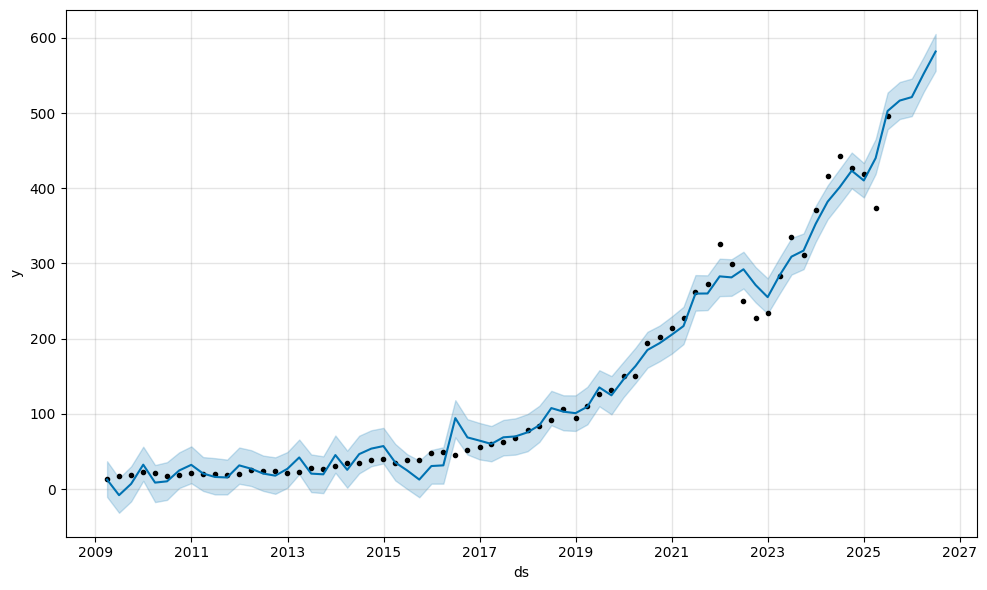

In [22]:
#12) PLOT THE RESULTS

figl = m.plot(forecast)
figl.show()

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_27827/3458915387.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figl_bt.show()


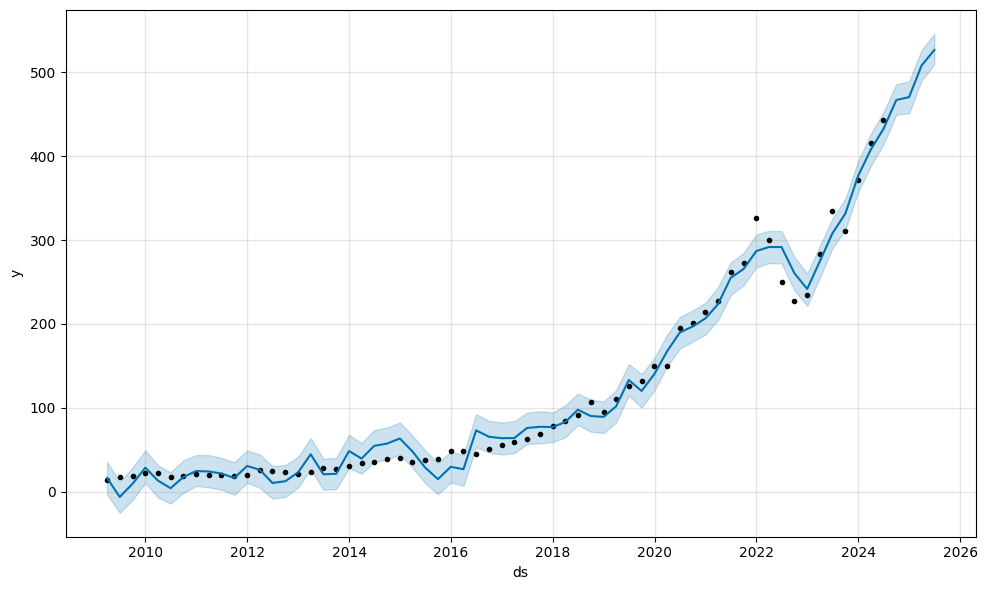

In [23]:
#12) PLOT THE RESULTS - BACKTESTING DATA

figl_bt = m_bt.plot(forecast_bt)
figl_bt.show()


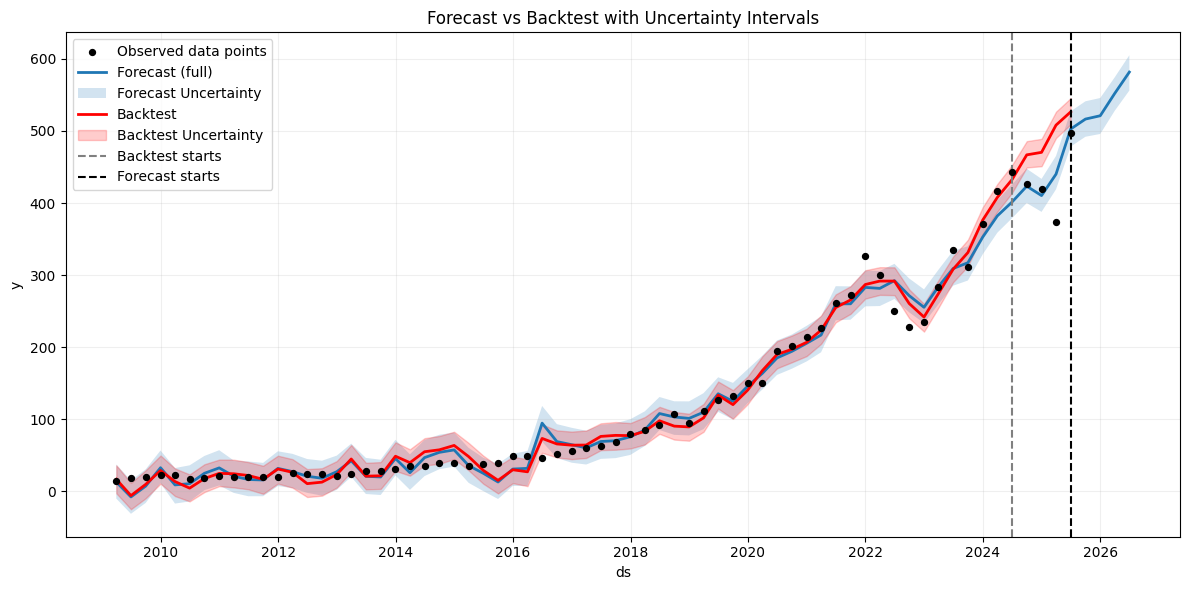

In [24]:
#13) PLOT THE FORECAST VS BACKTEST WITH UNCERTAINTY INTERVALS

# --- Ensure datetime dtype
results['ds'] = pd.to_datetime(results['ds'])
results_bt['ds'] = pd.to_datetime(results_bt['ds'])

# --- Find split dates
bt_split   = results_bt.loc[results_bt['is_future'].eq(False), 'ds'].max()   # ~2024-06-30
full_split = results.loc[results['is_future'].eq(False), 'ds'].max()         # ~2025-06-30

fig, ax = plt.subplots(figsize=(12,6))

# Actuals (dots) from full dataset
mask_actual = ~results['is_future']
ax.scatter(results.loc[mask_actual, 'ds'],
           results.loc[mask_actual, 'y'],
           s=18, label='Observed data points', zorder=3, color='k')

# Forecast (full) line + CI
ax.plot(results['ds'], results['yhat'], label='Forecast (full)', linewidth=2)
ax.fill_between(results['ds'], results['yhat_lower'], results['yhat_upper'],
                alpha=0.2, label='Forecast Uncertainty')

# Backtest line + CI
ax.plot(results_bt['ds'], results_bt['yhat'], label='Backtest', linewidth=2, color='red')
ax.fill_between(results_bt['ds'], results_bt['yhat_lower'], results_bt['yhat_upper'],
                alpha=0.2, label='Backtest Uncertainty', color='red')

# --- Vertical split lines
if pd.notna(bt_split):
    ax.axvline(bt_split, linestyle='--', linewidth=1.5, color='gray')
    # Dummy handle just for legend
    ax.plot([], [], linestyle='--', linewidth=1.5, color='gray', label='Backtest starts')

if pd.notna(full_split):
    ax.axvline(full_split, linestyle='--', linewidth=1.5, color='black')
    # Dummy handle just for legend
    ax.plot([], [], linestyle='--', linewidth=1.5, color='black', label='Forecast starts')

# Cosmetics
ax.set_title('Forecast vs Backtest with Uncertainty Intervals')
ax.set_xlabel('ds'); ax.set_ylabel('y')
# Deduplicate legend labels
handles, labels = ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), loc='upper left')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()